In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
train_df = pd.read_csv(r"C:\Users\Admin\mnisttt\HRE\train.csv")
test_df = pd.read_csv(r"C:\Users\Admin\mnisttt\HRE\test.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape :", test_df.shape)

Training data shape: (7352, 563)
Testing data shape : (2947, 563)


In [5]:
train_df.head()
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [6]:
print(train_df.columns)


Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)


In [7]:
print(train_df.head())

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

In [8]:
X_train = train_df.drop(["Activity", "subject"], axis=1)
y_train = train_df["Activity"]

X_test = test_df.drop(["Activity", "subject"], axis=1)
y_test = test_df["Activity"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (7352, 561)
y_train: (7352,)
X_test : (2947, 561)
y_test : (2947,)


In [9]:
print("Number of activities:", y_train.nunique())
print("\nActivities:")
print(y_train.unique())

Number of activities: 6

Activities:
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [10]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test : 0


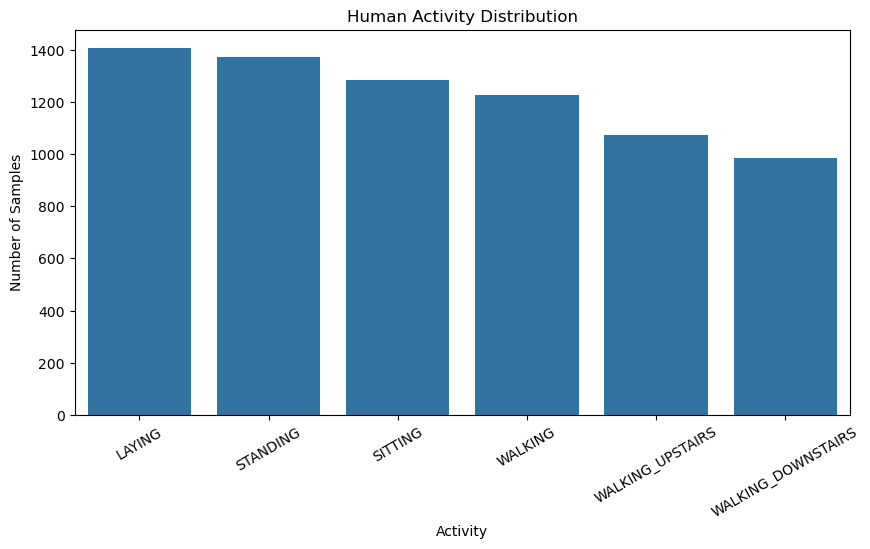

In [11]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x=y_train,
    order=y_train.value_counts().index
)

plt.title("Human Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)

plt.show()

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original features:", X_train.shape[1])
print("Features after PCA:", X_train_pca.shape[1])
print("X_train after PCA:", X_train_pca.shape)
print("X_test after PCA :", X_test_pca.shape)

Original features: 561
Features after PCA: 100
X_train after PCA: (7352, 100)
X_test after PCA : (2947, 100)


In [13]:
print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Total explained variance: 0.9730111912685049


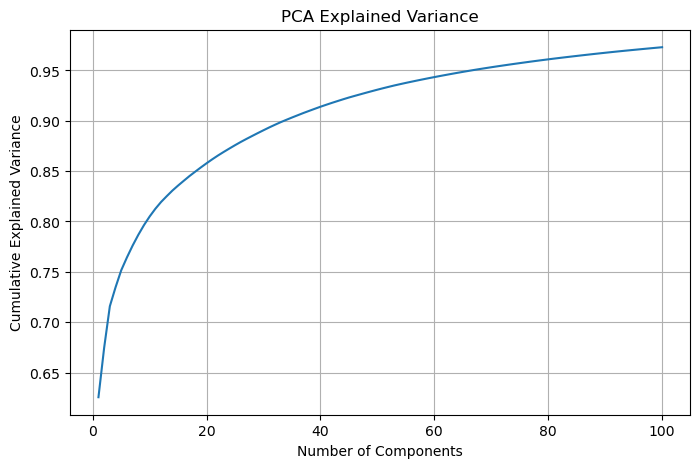

In [14]:
variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 101),
    variance
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)

print("KNN prediction completed!")

KNN prediction completed!


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_recall = recall_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average="weighted"
)

print("KNN Results")
print("----------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Results
----------------
Accuracy : 0.8961655921275874
Precision: 0.8987219425441433
Recall   : 0.8961655921275874
F1 Score : 0.8953008266164171


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.90      0.79      0.84       491
          STANDING       0.83      0.92      0.87       532
           WALKING       0.86      0.97      0.91       496
WALKING_DOWNSTAIRS       0.91      0.80      0.85       420
  WALKING_UPSTAIRS       0.90      0.88      0.89       471

          accuracy                           0.90      2947
         macro avg       0.90      0.89      0.89      2947
      weighted avg       0.90      0.90      0.90      2947



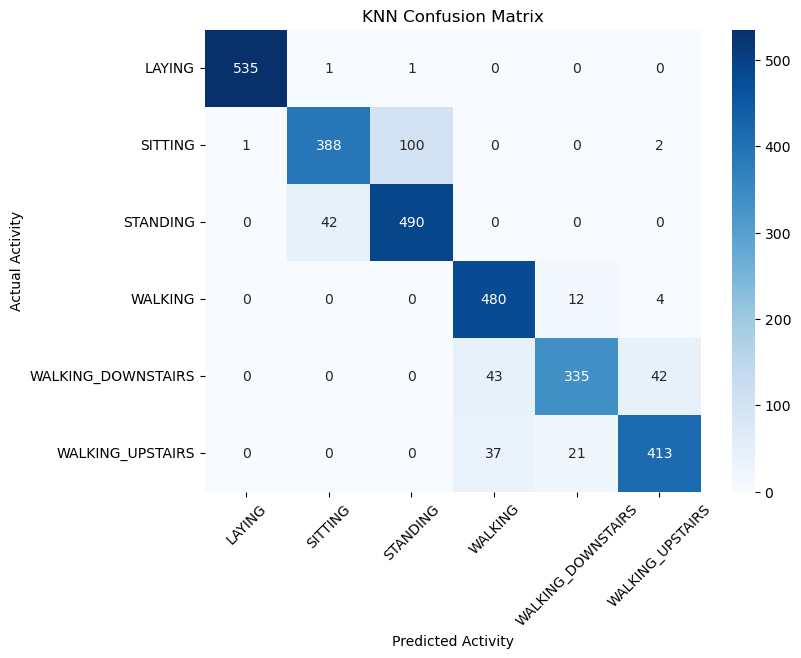

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("KNN Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt.fit(X_train_pca, y_train)

y_pred_dt = dt.predict(X_test_pca)

print("Decision Tree prediction completed!")

Decision Tree prediction completed!


In [20]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.8035290125551409
Precision: 0.8058416433557821
Recall   : 0.8035290125551409
F1 Score : 0.8038297772850582


In [21]:
print(classification_report(y_test, y_pred_dt))

                    precision    recall  f1-score   support

            LAYING       0.99      0.95      0.97       537
           SITTING       0.71      0.73      0.72       491
          STANDING       0.76      0.78      0.77       532
           WALKING       0.80      0.87      0.83       496
WALKING_DOWNSTAIRS       0.74      0.75      0.75       420
  WALKING_UPSTAIRS       0.82      0.72      0.77       471

          accuracy                           0.80      2947
         macro avg       0.80      0.80      0.80      2947
      weighted avg       0.81      0.80      0.80      2947



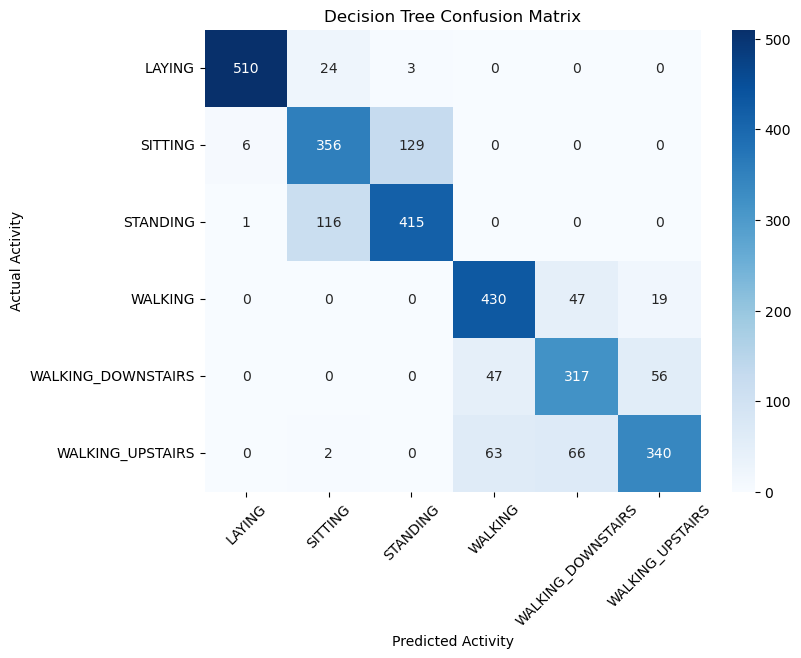

In [22]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("Decision Tree Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [23]:
X_train = train_df.drop(["Activity", "subject"], axis=1)
y_train = train_df["Activity"]

X_test = test_df.drop(["Activity", "subject"], axis=1)
y_test = test_df["Activity"]

print(X_train.shape)
print(X_test.shape)

(7352, 561)
(2947, 561)


In [24]:
X_train = train_df.drop(["Activity", "subject"], axis=1)
y_train = train_df["Activity"]

X_test = test_df.drop(["Activity", "subject"], axis=1)
y_test = test_df["Activity"]

print(X_train.shape)
print(X_test.shape)

(7352, 561)
(2947, 561)


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

y_pred_rf = rf.predict(X_test_pca)

print("Random Forest prediction completed!")

Random Forest prediction completed!


In [26]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
from sklearn.metrics import classification_report

Random Forest Results
---------------------
Accuracy : 0.9121140142517815
Precision: 0.9129779853940211
Recall   : 0.9121140142517815
F1 Score : 0.9118802949461522


In [27]:
print(classification_report(y_test, y_pred_rf))

                    precision    recall  f1-score   support

            LAYING       0.99      0.99      0.99       537
           SITTING       0.88      0.83      0.86       491
          STANDING       0.86      0.91      0.88       532
           WALKING       0.89      0.96      0.92       496
WALKING_DOWNSTAIRS       0.91      0.86      0.89       420
  WALKING_UPSTAIRS       0.94      0.92      0.93       471

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_train_pca)

print("K-Means clustering completed!")
print("Cluster labels:", np.unique(clusters))

K-Means clustering completed!
Cluster labels: [0 1 2 3 4 5]


In [29]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()

print(cluster_counts)

0     881
1     353
2    1892
3    1550
4    1393
5    1283
Name: count, dtype: int64


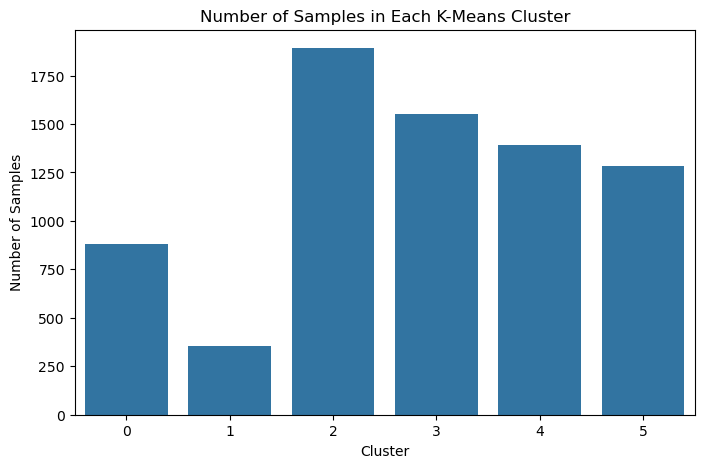

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Number of Samples in Each K-Means Cluster")

plt.show()

In [31]:
pca_2d = PCA(n_components=2)

X_train_2d = pca_2d.fit_transform(X_train)

print("2D PCA shape:", X_train_2d.shape)

2D PCA shape: (7352, 2)


In [33]:
kmeans_2d = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

clusters_2d = kmeans_2d.fit_predict(X_train_2d)

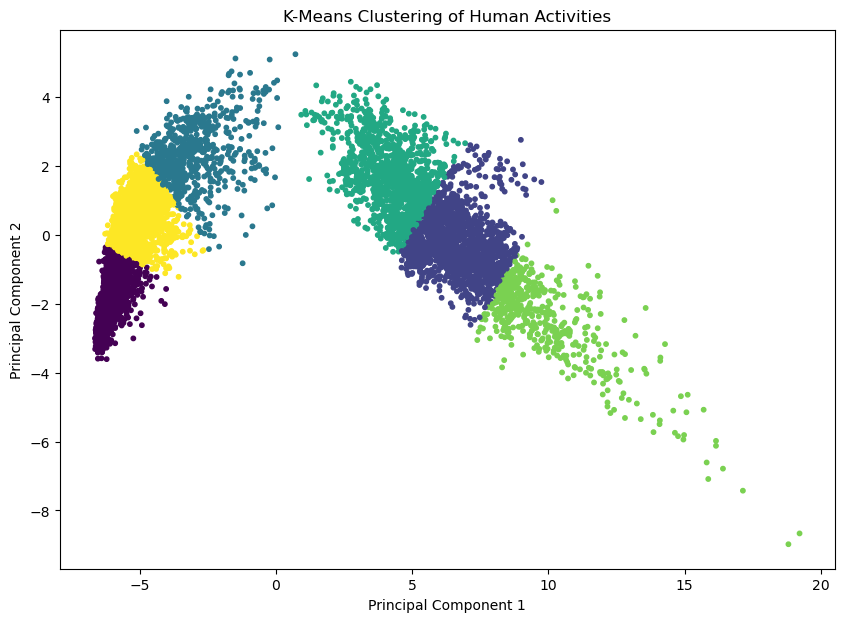

In [34]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=clusters_2d,
    s=10
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Human Activities")

plt.show()

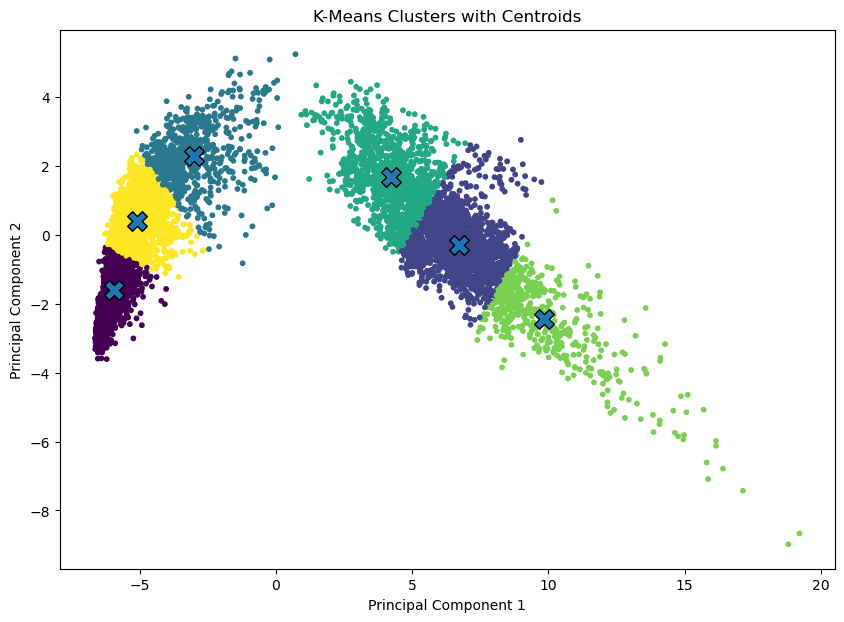

In [35]:
centers = kmeans_2d.cluster_centers_

plt.figure(figsize=(10, 7))

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=clusters_2d,
    s=10
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200,
    edgecolor="black"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters with Centroids")

plt.show()

In [36]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    y_train,
    clusters
)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.45582940033398656


In [37]:
results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [knn_accuracy, dt_accuracy, rf_accuracy],
    "Precision": [knn_precision, dt_precision, rf_precision],
    "Recall": [knn_recall, dt_recall, rf_recall],
    "F1 Score": [knn_f1, dt_f1, rf_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.896166,0.898722,0.896166,0.895301
1,Decision Tree,0.803529,0.805842,0.803529,0.803830
2,Random Forest,0.912114,0.912978,0.912114,0.911880


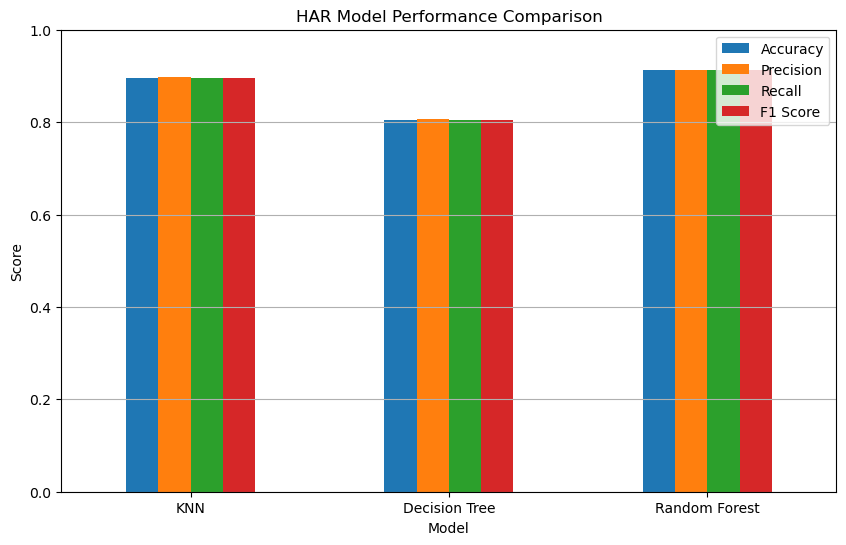

In [38]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("HAR Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [39]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])

Best Model: Random Forest
Accuracy: 0.9121140142517815


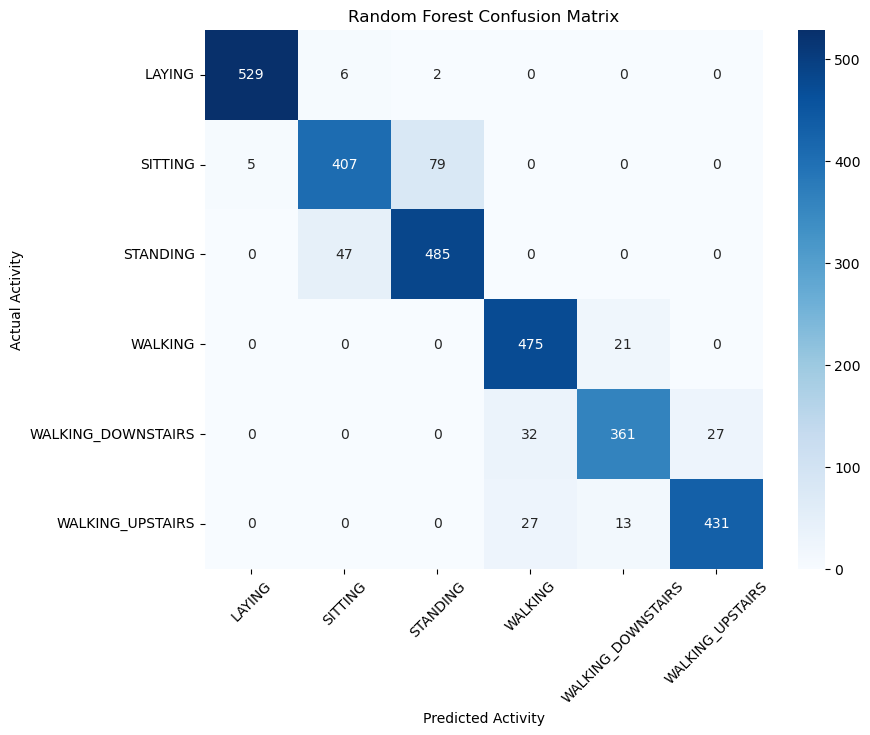

In [40]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("Random Forest Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()